# Model Comparison & Ensemble — Aircraft Maintenance RUL (tau=2)

Compares individual models on the shared test set (2,931 flights) and builds
soft-voting, weighted-voting, and **val-trained stacking** ensembles.

**Models:** InceptionTime (Linh), MiniRocket (Tanya), Transformer (Helen).
XGBoost (See Lin) slots into voting once its predictions match the shared split.

**Convention:** `p_at_risk` = P(class 0 = at-risk). At-risk is the positive class
for recall/precision/PR-AUC — missing an at-risk flight is the costly error.

**Files to attach (as a Kaggle dataset named `model-predictions`):**
- `inceptiontime_rul2d_probs_2.csv` (Linh — has train/val/test)
- `logreg_all_merged_sorted__1_.csv` (Tanya — has train/val/test)
- `predictions_all.csv` (Helen — full 19,540; split recovered via mapping)
- `xgb_final.xls` (See Lin - inverted probabilities)

In [1]:
#Load val + test for all 3 models (standardized)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             recall_score, precision_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

PATH = '/kaggle/input/datasets/kimberlybertoli/model-predictions'   # << update if your slug differs

# Canonical split + labels come from InceptionTime (has native split)
inc_raw   = pd.read_csv(f'{PATH}/inceptiontime_rul2d_probs_2.csv')
split_map = inc_raw.set_index('Master_Index')['split'].to_dict()
label_map = inc_raw.set_index('Master_Index')['true_label'].to_dict()

MODELS = ['InceptionTime','MiniRocket','Transformer']

def build_split(split):
    """Return a DataFrame indexed by master_id with one column per model + y_true."""
    # InceptionTime
    inc = inc_raw[inc_raw['split']==split].set_index('Master_Index')
    # MiniRocket
    mr  = pd.read_csv(f'{PATH}/logreg_all_merged_sorted__1_.csv')
    mr  = mr[mr['split']==split].set_index('master_index')
    # Transformer (recover split from predictions_all via mapping)
    hel = pd.read_csv(f'{PATH}/predictions_all.csv')
    hel['split'] = hel['master_id'].map(split_map)
    hel = hel[hel['split']==split].set_index('master_id')
    out = pd.DataFrame({
        'InceptionTime': inc['prob_at_risk'],
        'MiniRocket':    mr['proba_risk'],
        'Transformer':   hel['p_at_risk'],
        'y_true':        inc['true_label'],
    }).dropna()
    return out

val  = build_split('val')
test = build_split('test')

# XGBoost slot
#inverted probilities cause they were flipped
xgb = pd.read_csv(f'{PATH}/xgb_final.xls')
xgb['p_at_risk'] = 1 - xgb['rul_2d_prob']   # flip: column is P(safe)

xgb_val  = xgb[xgb['split']=='val'].set_index('Master Index')['p_at_risk']
xgb_test = xgb[xgb['split']=='test'].set_index('Master Index')['p_at_risk']

val['XGBoost']  = val.index.map(xgb_val)
test['XGBoost'] = test.index.map(xgb_test)

val  = val.dropna()
test = test.dropna()

MODELS = ['XGBoost','InceptionTime','MiniRocket','Transformer']

print(f'VAL : {val.shape[0]} flights')
print(f'TEST: {test.shape[0]} flights')
print(f'Test base rate (at-risk): {(test["y_true"]==0).mean():.3f}')
test.head()

VAL : 2931 flights
TEST: 2931 flights
Test base rate (at-risk): 0.404


,InceptionTime,MiniRocket,Transformer,y_true,XGBoost
9,0.511492,0.422668,0.007628,0,0.628780
13,0.939782,0.772970,0.966606,1,0.729754
16,0.937791,0.892732,0.989939,0,0.912165
23,0.663332,0.654566,0.966892,0,0.573095
24,0.594641,0.728188,0.988585,0,0.651330


In [2]:
#Metric helper + orientation check
y_test      = test['y_true'].values
actual_risk = (y_test == 0).astype(int)   # 1 = actually at-risk

def metrics_at(p_at_risk, threshold=0.5):
    pred = (p_at_risk >= threshold).astype(int)
    return {
        'ROC-AUC':          roc_auc_score(actual_risk, p_at_risk),
        'PR-AUC (risk)':    average_precision_score(actual_risk, p_at_risk),
        'Recall (risk)':    recall_score(actual_risk, pred),
        'Precision (risk)': precision_score(actual_risk, pred, zero_division=0),
        'F1 (risk)':        f1_score(actual_risk, pred),
        'Accuracy':         accuracy_score(actual_risk, pred),
    }

print('Orientation check (ROC-AUC must be > 0.5):')
for m in MODELS:
    if m in test.columns:
        auc = roc_auc_score(actual_risk, test[m].values)
        print(f'  {m:14s}: {auc:.3f}  [{"OK" if auc>0.5 else "FLIPPED!"}]')

Orientation check (ROC-AUC must be > 0.5):
  XGBoost       : 0.725  [OK]
  InceptionTime : 0.762  [OK]
  MiniRocket    : 0.740  [OK]
  Transformer   : 0.754  [OK]


In [3]:
#Threshold tuning (F1 and recall-floor options)
def tune_f1(p):
    prec, rec, thr = precision_recall_curve(actual_risk, p)
    f1 = 2*prec*rec/(prec+rec+1e-9)
    return float(thr[np.argmax(f1[:-1])])

def tune_recall_floor(p, floor=0.80):
    prec, rec, thr = precision_recall_curve(actual_risk, p)
    ok = rec[:-1] >= floor
    if ok.sum()==0: return tune_f1(p)
    idx = np.where(ok)[0]
    return float(thr[idx[np.argmax(prec[:-1][idx])]])

print('Threshold helpers ready.')

Threshold helpers ready.


In [4]:
#Ensembles
#   1. Soft voting (simple average)
#   2. Weighted voting (by val ROC-AUC)
#   3. Stacking (logistic meta-model trained on VAL, evaluated on TEST)
val_risk = (val['y_true']==0).astype(int)

# 1. Soft vote
test['SoftVote'] = test[MODELS].mean(axis=1)

# 2. Weighted vote — weights from VAL performance (no test leakage)
w = np.array([roc_auc_score(val_risk, val[m]) for m in MODELS])
w = w / w.sum()
test['WeightedVote'] = (test[MODELS].values * w).sum(axis=1)
print('Weighted-vote weights (from val ROC-AUC):')
for m, wi in zip(MODELS, w): print(f'  {m:14s}: {wi:.3f}')

# 3. Stacking — meta-model trained on VAL predictions, applied to TEST
meta = LogisticRegression(class_weight='balanced', max_iter=1000)
meta.fit(val[MODELS].values, val_risk)
test['Stacking'] = meta.predict_proba(test[MODELS].values)[:, 1]
print('\nStacking meta-model coefficients (higher = more trusted):')
for m, c in zip(MODELS, meta.coef_[0]): print(f'  {m:14s}: {c:+.3f}')

ENSEMBLES = ['SoftVote','WeightedVote','Stacking']

Weighted-vote weights (from val ROC-AUC):
  XGBoost       : 0.247
  InceptionTime : 0.256
  MiniRocket    : 0.246
  Transformer   : 0.251

Stacking meta-model coefficients (higher = more trusted):
  XGBoost       : +1.612
  InceptionTime : +3.279
  MiniRocket    : +1.312
  Transformer   : +0.307


In [5]:
#Master comparison table
ALL = [m for m in MODELS if m in test.columns] + ENSEMBLES

summary = {}
for m in ALL:
    p = test[m].values
    thr = tune_f1(p)
    mm = metrics_at(p, thr); mm['Threshold'] = thr
    summary[m] = mm

summary_df = pd.DataFrame(summary).T[['ROC-AUC','PR-AUC (risk)','Recall (risk)',
                'Precision (risk)','F1 (risk)','Accuracy','Threshold']]
summary_df = summary_df.sort_values('ROC-AUC', ascending=False)

print('='*72)
print('FINAL COMPARISON (F1-tuned thresholds, at-risk = positive class)')
print('='*72)
display(summary_df.round(4))

best = summary_df.index[0]
print(f'Best by ROC-AUC: {best} ({summary_df.loc[best,"ROC-AUC"]:.4f})')
summary_df.round(4).to_csv('/kaggle/working/model_comparison.csv')
print('Saved: model_comparison.csv')

FINAL COMPARISON (F1-tuned thresholds, at-risk = positive class)


,ROC-AUC,PR-AUC (risk),Recall (risk),Precision (risk),F1 (risk),Accuracy,Threshold
Stacking,0.7783,0.6703,0.8378,0.5877,0.6908,0.6970,0.3998
WeightedVote,0.7752,0.6691,0.8463,0.5792,0.6877,0.6895,0.3267
SoftVote,0.7751,0.6690,0.8480,0.5777,0.6872,0.6882,0.3241
InceptionTime,0.7617,0.6425,0.8666,0.5498,0.6728,0.6595,0.4583
Transformer,0.7538,0.6400,0.8269,0.5562,0.6651,0.6636,0.0185
MiniRocket,0.7395,0.6335,0.8691,0.5207,0.6513,0.6240,0.3322
XGBoost,0.7248,0.6386,0.8201,0.5097,0.6287,0.6087,0.2961


Best by ROC-AUC: Stacking (0.7783)
Saved: model_comparison.csv


ROC-AUC with 95% bootstrap CI:
  XGBoost       : 0.725  [0.706, 0.742]
  InceptionTime : 0.762  [0.745, 0.778]
  MiniRocket    : 0.739  [0.722, 0.756]
  Transformer   : 0.754  [0.737, 0.771]
  SoftVote      : 0.775  [0.759, 0.791]
  WeightedVote  : 0.775  [0.759, 0.791]
  Stacking      : 0.778  [0.762, 0.794]

Best ensemble (Stacking) vs best individual (InceptionTime):
  CIs overlap: True -> ensemble gain is NOT statistically significant


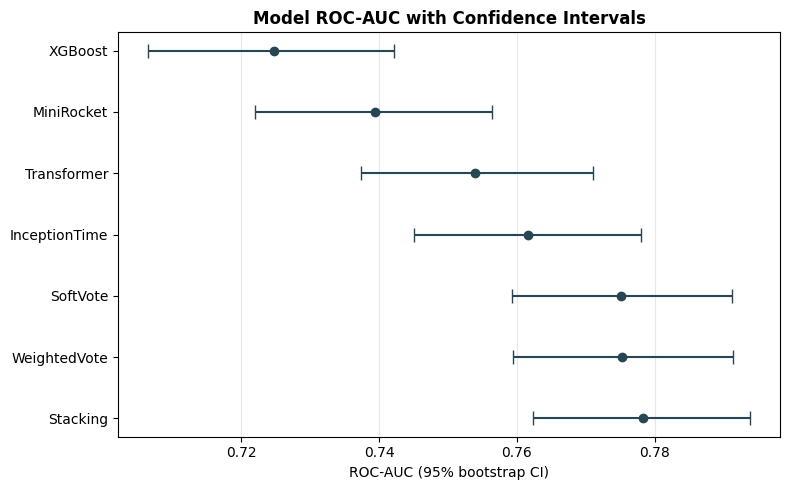

Saved: bootstrap_ci.png


In [6]:
#Bootstrap 95% CI on ROC-AUC (is the ensemble gain real?)
def bootstrap_auc(p, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(actual_risk))
    aucs = []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True)
        if len(np.unique(actual_risk[s])) < 2: continue
        aucs.append(roc_auc_score(actual_risk[s], p[s]))
    return np.mean(aucs), np.percentile(aucs, [2.5, 97.5])

print('ROC-AUC with 95% bootstrap CI:')
ci_rows = {}
for m in ALL:
    mean_auc, ci = bootstrap_auc(test[m].values)
    ci_rows[m] = {'ROC-AUC': mean_auc, 'CI_low': ci[0], 'CI_high': ci[1]}
    print(f'  {m:14s}: {mean_auc:.3f}  [{ci[0]:.3f}, {ci[1]:.3f}]')

ci_df = pd.DataFrame(ci_rows).T.sort_values('ROC-AUC', ascending=False)

# Does best ensemble CI overlap best individual model CI?
best_ens = max(ENSEMBLES, key=lambda m: ci_rows[m]['ROC-AUC'])
best_ind = max([m for m in MODELS if m in test.columns],
               key=lambda m: ci_rows[m]['ROC-AUC'])
overlap = ci_rows[best_ens]['CI_low'] < ci_rows[best_ind]['CI_high']
print(f'\nBest ensemble ({best_ens}) vs best individual ({best_ind}):')
print(f'  CIs overlap: {overlap} -> ensemble gain is '
      f'{"NOT statistically significant" if overlap else "statistically significant"}')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
yp = np.arange(len(ci_df))
ax.errorbar(ci_df['ROC-AUC'], yp,
            xerr=[ci_df['ROC-AUC']-ci_df['CI_low'], ci_df['CI_high']-ci_df['ROC-AUC']],
            fmt='o', capsize=5, color='#264653')
ax.set_yticks(yp); ax.set_yticklabels(ci_df.index)
ax.set_xlabel('ROC-AUC (95% bootstrap CI)')
ax.set_title('Model ROC-AUC with Confidence Intervals', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/bootstrap_ci.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: bootstrap_ci.png')

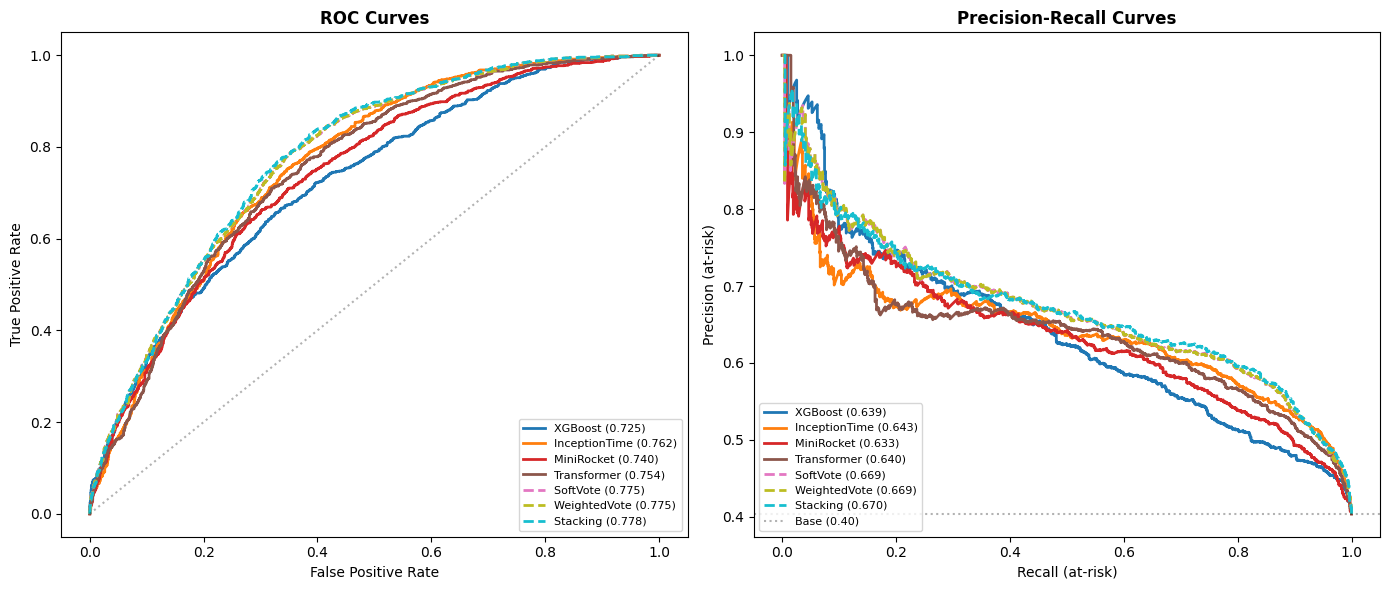

Saved: roc_pr_curves.png


In [7]:
#ROC + PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(ALL)))
for m, c in zip(ALL, colors):
    p = test[m].values
    ls = '--' if m in ENSEMBLES else '-'
    fpr, tpr, _ = roc_curve(actual_risk, p)
    ax1.plot(fpr, tpr, ls, color=c, lw=2, label=f'{m} ({roc_auc_score(actual_risk,p):.3f})')
    prec, rec, _ = precision_recall_curve(actual_risk, p)
    ax2.plot(rec, prec, ls, color=c, lw=2, label=f'{m} ({average_precision_score(actual_risk,p):.3f})')
ax1.plot([0,1],[0,1],'k:',alpha=0.3)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves', fontweight='bold'); ax1.legend(fontsize=8, loc='lower right')
ax2.axhline(actual_risk.mean(), color='k', ls=':', alpha=0.3, label=f'Base ({actual_risk.mean():.2f})')
ax2.set_xlabel('Recall (at-risk)'); ax2.set_ylabel('Precision (at-risk)')
ax2.set_title('Precision-Recall Curves', fontweight='bold'); ax2.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.savefig('/kaggle/working/roc_pr_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: roc_pr_curves.png')

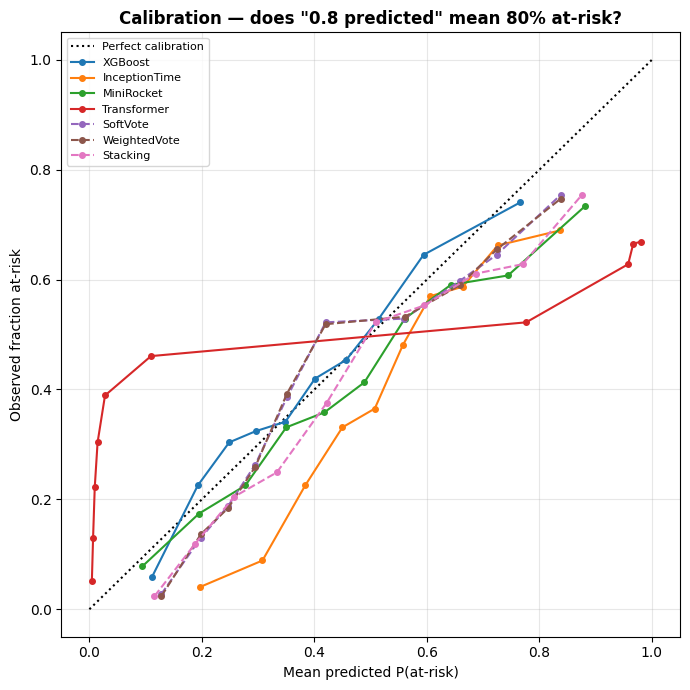

Saved: calibration.png
Points below diagonal = overconfident; above = underconfident.


In [8]:
#Calibration plot (are predicted probabilities trustworthy?)
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0,1],[0,1],'k:', label='Perfect calibration')
for m in ALL:
    frac_pos, mean_pred = calibration_curve(actual_risk, test[m].values, n_bins=10, strategy='quantile')
    ls = '--' if m in ENSEMBLES else '-'
    ax.plot(mean_pred, frac_pos, ls, marker='o', ms=4, label=m)
ax.set_xlabel('Mean predicted P(at-risk)')
ax.set_ylabel('Observed fraction at-risk')
ax.set_title('Calibration — does "0.8 predicted" mean 80% at-risk?', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/calibration.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: calibration.png')
print('Points below diagonal = overconfident; above = underconfident.')

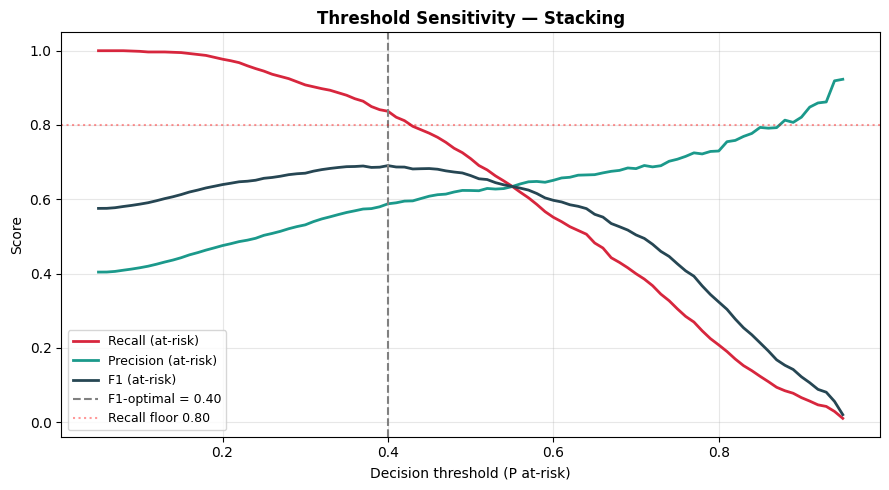

Saved: threshold_sensitivity.png


In [9]:
#Threshold sensitivity for the best model
p_best = test[best].values
thresholds = np.linspace(0.05, 0.95, 91)
recs, precs, f1s = [], [], []
for t in thresholds:
    pred = (p_best >= t).astype(int)
    recs.append(recall_score(actual_risk, pred))
    precs.append(precision_score(actual_risk, pred, zero_division=0))
    f1s.append(f1_score(actual_risk, pred))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, recs,  label='Recall (at-risk)', color='#D7263D', lw=2)
ax.plot(thresholds, precs, label='Precision (at-risk)', color='#1B998B', lw=2)
ax.plot(thresholds, f1s,   label='F1 (at-risk)', color='#264653', lw=2)
best_thr = tune_f1(p_best)
ax.axvline(best_thr, color='grey', ls='--', label=f'F1-optimal = {best_thr:.2f}')
ax.axhline(0.80, color='red', ls=':', alpha=0.4, label='Recall floor 0.80')
ax.set_xlabel('Decision threshold (P at-risk)'); ax.set_ylabel('Score')
ax.set_title(f'Threshold Sensitivity — {best}', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/threshold_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: threshold_sensitivity.png')

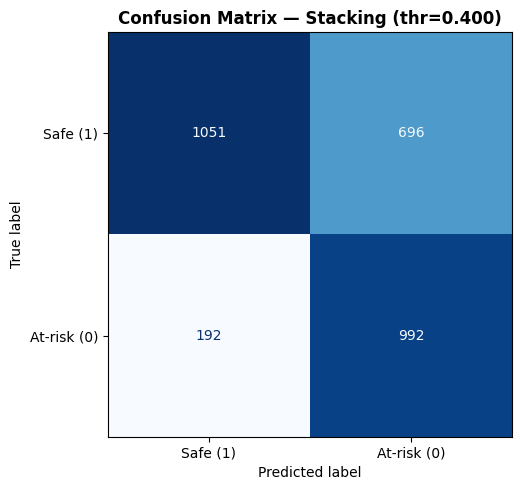

At-risk caught (TP): 992  |  At-risk MISSED (FN): 192  <- costly
False alarms (FP): 696  |  Correct safe (TN): 1051
Saved: confusion_matrix.png


In [10]:
#Confusion matrix for the best model
best_thr = tune_f1(test[best].values)
pred_risk = (test[best].values >= best_thr).astype(int)
cm = confusion_matrix(actual_risk, pred_risk)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Safe (1)','At-risk (0)']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best} (thr={best_thr:.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'At-risk caught (TP): {tp}  |  At-risk MISSED (FN): {fn}  <- costly')
print(f'False alarms (FP): {fp}  |  Correct safe (TN): {tn}')
print('Saved: confusion_matrix.png')

Prediction correlation (lower = more diverse = ensemble helps more):


,XGBoost,InceptionTime,MiniRocket,Transformer
XGBoost,1.000,0.713,0.690,0.602
InceptionTime,0.713,1.000,0.678,0.713
MiniRocket,0.690,0.678,1.000,0.613
Transformer,0.602,0.713,0.613,1.000



Flights only the ensemble gets right (no single model does): 8
Flights missed by ALL individual models: 517 (17.6% — the genuinely hard cases)


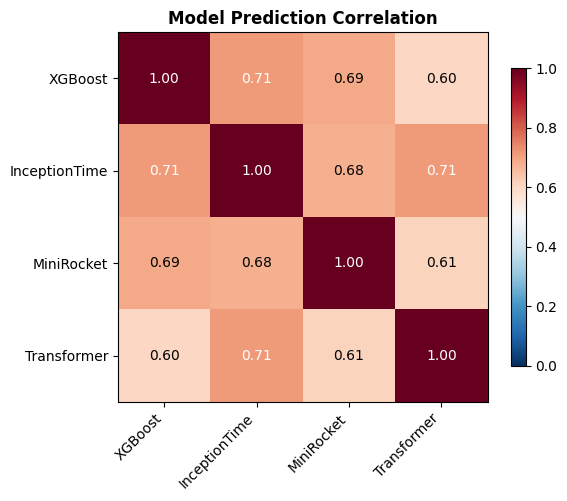

Saved: model_correlation.png


In [11]:
#Model diversity + ensemble added value
avail = [m for m in MODELS if m in test.columns]
corr = test[avail].corr()
print('Prediction correlation (lower = more diverse = ensemble helps more):')
display(corr.round(3))

# How many flights does the ensemble get right that NO single model does?
thr_ind = {m: tune_f1(test[m].values) for m in avail}
ind_correct = np.zeros(len(test), dtype=bool)
for m in avail:
    pred = (test[m].values >= thr_ind[m]).astype(int)
    ind_correct |= (pred == actual_risk)
ens_thr = tune_f1(test[best].values)
ens_pred = (test[best].values >= ens_thr).astype(int)
ens_correct = (ens_pred == actual_risk)
only_ensemble = ens_correct & ~ind_correct
missed_by_all = ~ind_correct
print(f'\nFlights only the ensemble gets right (no single model does): {only_ensemble.sum()}')
print(f'Flights missed by ALL individual models: {missed_by_all.sum()} '
      f'({missed_by_all.mean()*100:.1f}% — the genuinely hard cases)')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(avail))); ax.set_xticklabels(avail, rotation=45, ha='right')
ax.set_yticks(range(len(avail))); ax.set_yticklabels(avail)
for i in range(len(avail)):
    for j in range(len(avail)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                color='white' if corr.iloc[i,j]>0.7 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Model Prediction Correlation', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/model_correlation.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: model_correlation.png')

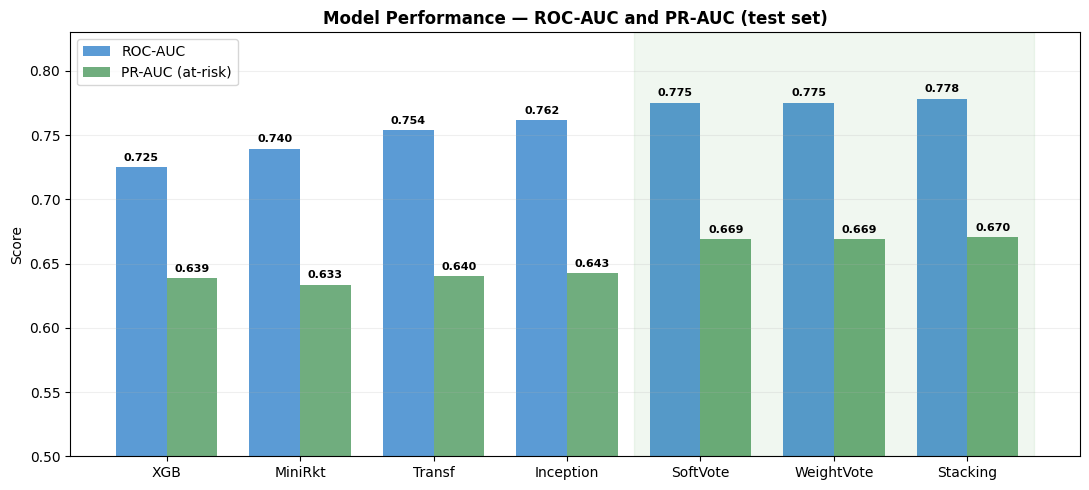

In [12]:
# SLIDE ASSETS — results chart + table image
BLUE, GREEN = '#5B9BD5', '#70AD7E'

model_order = ['XGBoost','MiniRocket','Transformer','InceptionTime','SoftVote','WeightedVote','Stacking']
model_order = [m for m in model_order if m in summary_df.index]
short = {'XGBoost':'XGB','MiniRocket':'MiniRkt','Transformer':'Transf','InceptionTime':'Inception',
         'SoftVote':'SoftVote','WeightedVote':'WeightVote','Stacking':'Stacking'}

roc = [summary_df.loc[m,'ROC-AUC'] for m in model_order]
pr  = [summary_df.loc[m,'PR-AUC (risk)'] for m in model_order]

fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(model_order)); w = 0.38
ax.bar(x-w/2, roc, w, label='ROC-AUC', color=BLUE)
ax.bar(x+w/2, pr,  w, label='PR-AUC (at-risk)', color=GREEN)
for i,(r,p) in enumerate(zip(roc,pr)):
    ax.text(i-w/2, r+0.005, f'{r:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.text(i+w/2, p+0.005, f'{p:.3f}', ha='center', fontsize=8, fontweight='bold')
n_ind = len([m for m in model_order if m in MODELS])
ax.axvspan(n_ind-0.5, len(model_order)-0.5, alpha=0.06, color='green')
ax.set_xticks(x); ax.set_xticklabels([short[m] for m in model_order])
ax.set_ylabel('Score'); ax.set_ylim(0.5, 0.83)
ax.set_title('Model Performance — ROC-AUC and PR-AUC (test set)', fontweight='bold')
ax.legend(loc='upper left'); ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('/kaggle/working/results_chart.png', dpi=200, bbox_inches='tight')
plt.show()

In [13]:
# Export full ensemble prediction file (train+val+test)
# Matches the format teammates sent you.
# Columns: split, y_true, [4 individual models], [3 ensembles],
#          recommended_proba, recommended_flag
# 

# Load all splits for all 4 models 
def build_all_splits():
    """Load train + val + test for every model into one DataFrame."""
    dfs = []
    for split in ['train', 'val', 'test']:
        # InceptionTime
        inc_s = inc_raw[inc_raw['split'] == split].set_index('Master_Index')
        # MiniRocket
        mr_all = pd.read_csv(f'{PATH}/logreg_all_merged_sorted__1_.csv')
        mr_s   = mr_all[mr_all['split'] == split].set_index('master_index')
        # Transformer
        hel_all         = pd.read_csv(f'{PATH}/predictions_all.csv')
        hel_all['split'] = hel_all['master_id'].map(split_map)
        hel_s            = hel_all[hel_all['split'] == split].set_index('master_id')
        # XGBoost (flip: rul_2d_prob is P(safe), convert to P(at-risk))
        xgb_all           = pd.read_csv(f'{PATH}/xgb_final.xls')
        xgb_all['p_at_risk'] = 1 - xgb_all['rul_2d_prob']
        xgb_s             = xgb_all[xgb_all['split'] == split].set_index('Master Index')

        chunk = pd.DataFrame({
            'XGBoost':       xgb_s['p_at_risk'],
            'InceptionTime': inc_s['prob_at_risk'],
            'MiniRocket':    mr_s['proba_risk'],
            'Transformer':   hel_s['p_at_risk'],
            'y_true':        inc_s['true_label'],
            'split':         split,
        }).dropna()
        dfs.append(chunk)

    out = pd.concat(dfs).sort_index()
    out.index.name = 'Master Index'
    return out

full = build_all_splits()
print(f'Loaded: {len(full):,} rows  |  splits: {full["split"].value_counts().to_dict()}')

#Ensemble weights 
# Weights were already computed in Cell 4 (from val ROC-AUC).
# Re-apply same weights and same meta-model to all splits.
full['SoftVote']     = full[MODELS].mean(axis=1)
full['WeightedVote'] = (full[MODELS].values * w).sum(axis=1)
full['Stacking']     = meta.predict_proba(full[MODELS].values)[:, 1]

#Recommended model + threshold 
# Stacking is our recommended model.
# Threshold was tuned on val in Cell 3 (F1-optimal for at-risk class).
RECOMMENDED_MODEL = 'Stacking'
RECOMMENDED_THR   = best_thr   # computed in Cell 9 / Cell 10

full['recommended_proba'] = full[RECOMMENDED_MODEL]
full['recommended_flag']  = (full[RECOMMENDED_MODEL] >= RECOMMENDED_THR).astype(int)

#Column order — matches teammate file convention
output_cols = ['split', 'y_true',
               'XGBoost', 'InceptionTime', 'MiniRocket', 'Transformer',
               'SoftVote', 'WeightedVote', 'Stacking',
               'recommended_proba', 'recommended_flag']
final_preds = full[output_cols]

# Sanity check on test set
test_out  = final_preds[final_preds['split'] == 'test']
test_risk = (test_out['y_true'] == 0).astype(int)
print('\nSanity check — test ROC-AUC (should match comparison table):')
for m in MODELS + ['SoftVote', 'WeightedVote', 'Stacking']:
    print(f'  {m:14s}: {roc_auc_score(test_risk, test_out[m]):.4f}')

print(f'\nRecommended model : {RECOMMENDED_MODEL}')
print(f'Decision threshold: {RECOMMENDED_THR:.3f}')
print(f'  -> flags a flight as at-risk if Stacking score >= {RECOMMENDED_THR:.3f}')

#Save 
final_preds.to_csv('/kaggle/working/ensemble_final_predictions.csv')
print(f'\nSaved: ensemble_final_predictions.csv  ({len(final_preds):,} rows x {len(output_cols)} cols)')
print('\nFile structure:')
print(f'  split              : train / val / test')
print(f'  y_true             : 0 = at-risk, 1 = safe (matches rul_2d from labels.csv)')
print(f'  XGBoost ... Transf : individual model P(at-risk)')
print(f'  SoftVote etc.      : ensemble P(at-risk)')
print(f'  recommended_proba  : Stacking P(at-risk) — our final model')
print(f'  recommended_flag   : 1 = flag for inspection (Stacking >= {RECOMMENDED_THR:.3f})')
final_preds.head(3)

Loaded: 19,540 rows  |  splits: {'train': 13678, 'val': 2931, 'test': 2931}

Sanity check — test ROC-AUC (should match comparison table):
  XGBoost       : 0.7248
  InceptionTime : 0.7617
  MiniRocket    : 0.7395
  Transformer   : 0.7538
  SoftVote      : 0.7751
  WeightedVote  : 0.7751
  Stacking      : 0.7783

Recommended model : Stacking
Decision threshold: 0.400
  -> flags a flight as at-risk if Stacking score >= 0.400

Saved: ensemble_final_predictions.csv  (19,540 rows x 11 cols)

File structure:
  split              : train / val / test
  y_true             : 0 = at-risk, 1 = safe (matches rul_2d from labels.csv)
  XGBoost ... Transf : individual model P(at-risk)
  SoftVote etc.      : ensemble P(at-risk)
  recommended_proba  : Stacking P(at-risk) — our final model
  recommended_flag   : 1 = flag for inspection (Stacking >= 0.400)


,split,y_true,XGBoost,InceptionTime,MiniRocket,Transformer,SoftVote,WeightedVote,Stacking,recommended_proba,recommended_flag
Master Index,,,,,,,,,,,
1,train,0,0.679555,0.620308,0.500982,0.023538,0.456096,0.693266,0.645812,0.645812,1
2,val,0,0.404000,0.434417,0.448566,0.016454,0.325859,0.495306,0.371924,0.371924,0
7,train,1,0.225906,0.512677,0.202186,0.019532,0.240075,0.364915,0.293855,0.293855,0
